**MODEL EVALUATION**

In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

In [50]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

if project_root not in sys.path:
    sys.path.append(project_root)

from src import config
PROCESSED_DATA_PATH = config.PROCESSED_DATA_PATH
MODEL_DIR = config.MODEL_PATH
BEST_PARAMS_PATH = config.PARAM_PATH
TFIFD_VEC_PATH = config.TFIFD_VEC_PATH
TAGS_VEC_PATH = config.TAGS_VEC_PATH
GENRES_VEC_PATH = config.GENRES_VEC_PATH
TFIFD_MATRIX_PATH = config.TFIFD_MATRIX_PATH
TAGS_MATRIX_PATH = config.TAGS_MATRIX_PATH
GENRES_MATRIX_PATH = config.GENRES_MATRIX_PATH

In [51]:
df = pd.read_csv(PROCESSED_DATA_PATH)

In [52]:
df["description"] = df["description"].fillna("")

In [53]:
drop_cols = ['id', 'desc_word_count']
df_clean = df.drop(columns=drop_cols, errors='ignore')

In [54]:
df_clean = df_clean.drop(columns=['favourites'], errors='ignore')

In [55]:
scaler = MinMaxScaler()
numerical_cols = ['chapters', 'popularity', 'averageScore', 'desc_char_len', 'sentiment_score', 'tag_count']
df_num = df_clean[numerical_cols]
df_num = scaler.fit_transform(df_clean[numerical_cols])

In [56]:
df_num = pd.DataFrame(df_num)

In [57]:
df_num.columns = numerical_cols

In [58]:
pca = PCA(n_components=None)
pca.fit(df_num)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [59]:
pca_components = pd.DataFrame(pca.components_, columns=numerical_cols)

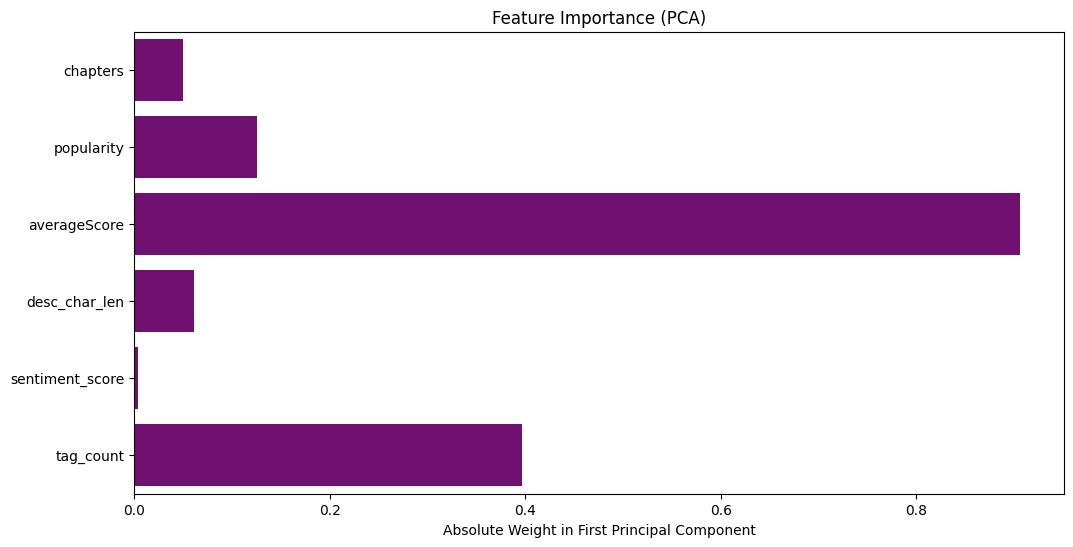

In [60]:
plt.figure(figsize=(12, 6))
sns.barplot(x=pca_components.iloc[0].abs(), y=numerical_cols, color='purple')
plt.title("Feature Importance (PCA)")
plt.xlabel("Absolute Weight in First Principal Component")
plt.show()

In [61]:
weighted_df = df.copy()
genre_cols = [c for c in df_clean.columns if 'is_' in c]

In [62]:
for col in weighted_df.columns:
    if weighted_df[col].dtype == 'bool':
        weighted_df[col] = weighted_df[col].astype(int)

weighted_df = weighted_df.select_dtypes(include=[np.number])

In [63]:
for col in genre_cols:
    weighted_df[col] = weighted_df[col] * 2.0

In [64]:
tfidf = TfidfVectorizer(stop_words='english', max_features=100)
tfidf_matrix = tfidf.fit_transform(df['description'].fillna(''))

In [65]:
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

In [66]:
final_rec_df = pd.concat([weighted_df.drop(columns=['sentiment_score']), tfidf_df], axis=1)

In [72]:
cosine_sim = cosine_similarity(final_rec_df)

In [73]:
sample_idx = 0 
similar_indices = cosine_sim[sample_idx].argsort()[:-6:-1]

In [75]:
print(f"Chosen ID: {df.iloc[sample_idx]['title_romaji']} (Features: {df_clean.iloc[sample_idx].to_dict()})")
print("\n-Reccomendations")
for i in similar_indices:
    if i != sample_idx:
        print(f"ID: {df.iloc[i]['title_romaji']} | Score: {cosine_sim[sample_idx][i]:.4f} | Genres: {[col for col in df.columns if 'is_' in col and df.iloc[i][col]==1]}")

Chosen ID: Chainsaw Man (Features: {'Unnamed: 0': 0, 'title_romaji': 'Chainsaw Man', 'format': 'MANGA', 'chapters': 28.0, 'genres': "['Action', 'Comedy', 'Drama', 'Horror', 'Supernatural']", 'tags': "['demons', 'tragedy', 'urban fantasy', 'dissociative identities', 'coming of age', 'male protagonist', 'gore', 'body horror', 'psychosexual', 'cosmic horror', 'henshin', 'female protagonist', 'urban', 'monster boy', 'survival', 'found family', 'work', 'ensemble cast', 'memory manipulation', 'shounen', 'yandere', 'cult', 'heterosexual', 'guns', 'assassins', 'monster girl', 'human pet', 'femdom', 'revenge', 'terrorism', 'shapeshifting', 'slapstick', 'meta', 'philosophy', 'afterlife', 'primarily teen cast', 'nudity', 'delinquents', 'cannibalism', 'school', 'angels', 'amnesia', 'necromancy', 'time skip', 'politics', 'yakuza', 'mafia', 'lgbtq+ themes', 'tsundere', 'zombie', 'chimera', 'motorcycles', 'surreal comedy', 'vore']", 'country': 'JP', 'popularity': 298644, 'averageScore': 85.0, 'status

The model is so fixed on "popularity" feature so all the reccomendations are very popular titles. But I also want the model to reccomendt some unpopular ones so I will adjust the weight of "popularity"

In [84]:
df_num['popularity'] = np.log1p(df_clean['popularity'])

In [90]:
test_df = df_num.copy()

In [91]:
genre_cols = [c for c in test_df.columns if 'is_' in c]
for col in genre_cols:
    test_df[col] = test_df[col] * 50.0

In [94]:
cosine_sim_test = cosine_similarity(test_df)

In [95]:
sample_idx = 0 
similar_indices = cosine_sim_test[sample_idx].argsort()[:-6:-1]

In [ ]:
print(f"Chosen ID: {df.iloc[sample_idx]['title_romaji']} (Features: {df_clean.iloc[sample_idx].to_dict()})")
print("\n-Reccomendations")
for i in similar_indices:
    if i != sample_idx:
        print(f"ID: {df.iloc[i]['title_romaji']} | Score: {cosine_sim[sample_idx][i]:.4f} | Genres: {[col for col in df.columns if 'is_' in col and df.iloc[i][col]==1]}")

Chosen ID: Chainsaw Man (Features: {'Unnamed: 0': 0, 'title_romaji': 'Chainsaw Man', 'format': 'MANGA', 'chapters': 28.0, 'genres': "['Action', 'Comedy', 'Drama', 'Horror', 'Supernatural']", 'tags': "['demons', 'tragedy', 'urban fantasy', 'dissociative identities', 'coming of age', 'male protagonist', 'gore', 'body horror', 'psychosexual', 'cosmic horror', 'henshin', 'female protagonist', 'urban', 'monster boy', 'survival', 'found family', 'work', 'ensemble cast', 'memory manipulation', 'shounen', 'yandere', 'cult', 'heterosexual', 'guns', 'assassins', 'monster girl', 'human pet', 'femdom', 'revenge', 'terrorism', 'shapeshifting', 'slapstick', 'meta', 'philosophy', 'afterlife', 'primarily teen cast', 'nudity', 'delinquents', 'cannibalism', 'school', 'angels', 'amnesia', 'necromancy', 'time skip', 'politics', 'yakuza', 'mafia', 'lgbtq+ themes', 'tsundere', 'zombie', 'chimera', 'motorcycles', 'surreal comedy', 'vore']", 'country': 'JP', 'popularity': 298644, 'averageScore': 85.0, 'status